# NIGENS Human vs Non-Human

Bu notebook yalnizca NIGENS veri seti ile calisir. `baby` sinifi tamamen dislanir, `general` sinifindan ise ilk deney icin en fazla 100 ornek kullanilir.

## 1. Imports

In [1]:
import math
import random
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from scipy.signal import butter, sosfiltfilt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 2. Config

In [2]:
PROJECT_ROOT = Path(r"C:\projs\echo_swarm2")
DATA_ROOT = PROJECT_ROOT / "dataset" / "nigens" / "NIGENS" / "NIGENS"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODELS_DIR / "nigens_best.pt"

NOTEBOOKS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
SAMPLE_RATE = 16_000
CLIP_SECONDS = 1.5
CLIP_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)
GENERAL_MAX_SAMPLES = 100
TEST_SIZE = 0.20
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
LOWPASS_PROB = 0.35
NOISE_PROB = 0.35
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Data root: {DATA_ROOT}")
print(f"Model path: {MODEL_PATH}")


Device: cuda
Data root: C:\projs\echo_swarm2\dataset\nigens\NIGENS\NIGENS
Model path: C:\projs\echo_swarm2\models\nigens_best.pt


## 3. NIGENS Sinif Eslemesi

In [3]:
HUMAN_CLASSES = [
    "femaleScream",
    "maleScream",
    "femaleSpeech",
    "maleSpeech",
]

NON_HUMAN_CLASSES = [
    "alarm",
    "crash",
    "dog",
    "engine",
    "fire",
    "footsteps",
    "knock",
    "phone",
    "piano",
    "general",
]

EXCLUDED_CLASSES = ["baby"]

SOURCE_TO_TARGET = {name: "HUMAN" for name in HUMAN_CLASSES}
SOURCE_TO_TARGET.update({name: "NON_HUMAN" for name in NON_HUMAN_CLASSES})

LABEL_TO_IDX = {"NON_HUMAN": 0, "HUMAN": 1}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

mapping_df = pd.DataFrame(
    [
        {"source_class": source_class, "target_label": target_label}
        for source_class, target_label in SOURCE_TO_TARGET.items()
    ]
).sort_values(["target_label", "source_class"]).reset_index(drop=True)

display(mapping_df)
print(f"Excluded classes: {EXCLUDED_CLASSES}")
print(f"'general' icin maksimum ornek: {GENERAL_MAX_SAMPLES}")


,source_class,target_label
0,femaleScream,HUMAN
1,femaleSpeech,HUMAN
2,maleScream,HUMAN
3,maleSpeech,HUMAN
4,alarm,NON_HUMAN
5,crash,NON_HUMAN
6,dog,NON_HUMAN
7,engine,NON_HUMAN
8,fire,NON_HUMAN
9,footsteps,NON_HUMAN


Excluded classes: ['baby']
'general' icin maksimum ornek: 100


## 4. Dosyalari Toplama

In [4]:
def collect_nigens_records(data_root: Path, seed: int = SEED) -> pd.DataFrame:
    records = []
    sampler = random.Random(seed)

    for source_class, target_label in SOURCE_TO_TARGET.items():
        class_dir = data_root / source_class
        if not class_dir.exists():
            raise FileNotFoundError(f"Sinif klasoru bulunamadi: {class_dir}")

        wav_paths = sorted(path for path in class_dir.glob("*.wav") if path.is_file())
        if source_class == "general":
            limit = min(GENERAL_MAX_SAMPLES, len(wav_paths))
            wav_paths = sorted(sampler.sample(wav_paths, k=limit))

        for wav_path in wav_paths:
            records.append(
                {
                    "path": str(wav_path),
                    "source_class": source_class,
                    "target_label": target_label,
                    "label_idx": LABEL_TO_IDX[target_label],
                }
            )

    df = pd.DataFrame(records)
    if df.empty:
        raise RuntimeError("Toplanan kayit bulunamadi. DATA_ROOT yolunu kontrol edin.")
    return df


all_df = collect_nigens_records(DATA_ROOT)
print(f"Toplam secilen ornek sayisi: {len(all_df)}")

source_counts = (
    all_df["source_class"]
    .value_counts()
    .rename_axis("source_class")
    .reset_index(name="count")
    .sort_values("source_class")
    .reset_index(drop=True)
)
label_counts = (
    all_df["target_label"]
    .value_counts()
    .rename_axis("target_label")
    .reset_index(name="count")
    .sort_values("target_label")
    .reset_index(drop=True)
)

display(source_counts)
display(label_counts)
all_df.head()


Toplam secilen ornek sayisi: 655


,source_class,count
0,alarm,50
1,crash,50
2,dog,45
3,engine,39
4,femaleScream,45
5,femaleSpeech,40
6,fire,51
7,footsteps,42
8,general,100
9,knock,40


,target_label,count
0,HUMAN,156
1,NON_HUMAN,499


,path,source_class,target_label,label_idx
0,C:\projs\echo_swarm2\dataset\nigens\NIGENS\NIG...,femaleScream,HUMAN,1
1,C:\projs\echo_swarm2\dataset\nigens\NIGENS\NIG...,femaleScream,HUMAN,1
2,C:\projs\echo_swarm2\dataset\nigens\NIGENS\NIG...,femaleScream,HUMAN,1
3,C:\projs\echo_swarm2\dataset\nigens\NIGENS\NIG...,femaleScream,HUMAN,1
4,C:\projs\echo_swarm2\dataset\nigens\NIGENS\NIG...,femaleScream,HUMAN,1


## 5. Train / Val Split

In [5]:
train_df, val_df = train_test_split(
    all_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=all_df["target_label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print("\nTrain label dagilimi:")
display(train_df["target_label"].value_counts().rename_axis("label").reset_index(name="count"))
print("\nVal label dagilimi:")
display(val_df["target_label"].value_counts().rename_axis("label").reset_index(name="count"))


Train size: 524
Val size: 131

Train label dagilimi:


,label,count
0,NON_HUMAN,399
1,HUMAN,125



Val label dagilimi:


,label,count
0,NON_HUMAN,100
1,HUMAN,31


## 6. WAV Preprocess

In [6]:
def load_audio(path: str, target_sr: int = SAMPLE_RATE) -> np.ndarray:
    waveform, sr = librosa.load(path, sr=None, mono=True)
    waveform = waveform.astype(np.float32)
    if sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
    return waveform.astype(np.float32)


def crop_or_pad(waveform: np.ndarray, target_length: int = CLIP_SAMPLES, training: bool = False) -> np.ndarray:
    current_length = len(waveform)
    if current_length > target_length:
        if training:
            start = random.randint(0, current_length - target_length)
        else:
            start = (current_length - target_length) // 2
        waveform = waveform[start : start + target_length]
    elif current_length < target_length:
        pad_total = target_length - current_length
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        waveform = np.pad(waveform, (pad_left, pad_right), mode="constant")
    return waveform.astype(np.float32)


sample_wave = load_audio(train_df.loc[0, "path"])
sample_wave = crop_or_pad(sample_wave, training=False)
print(f"Ornek waveform boyutu: {sample_wave.shape}")
print(f"Sure (sn): {len(sample_wave) / SAMPLE_RATE:.2f}")


Ornek waveform boyutu: (24000,)
Sure (sn): 1.50


## 7. Augment

In [7]:
def apply_lowpass(waveform: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    cutoff = random.uniform(2500.0, 5500.0)
    nyquist = sr / 2.0
    cutoff = min(cutoff, nyquist * 0.95)
    sos = butter(N=6, Wn=cutoff / nyquist, btype="low", output="sos")
    filtered = sosfiltfilt(sos, waveform).astype(np.float32)
    return filtered


def add_gaussian_noise(waveform: np.ndarray) -> np.ndarray:
    noise_scale = random.uniform(0.001, 0.01)
    noise = np.random.normal(0.0, noise_scale, size=waveform.shape).astype(np.float32)
    return (waveform + noise).astype(np.float32)


def augment_waveform(waveform: np.ndarray) -> np.ndarray:
    augmented = waveform.copy()
    if random.random() < LOWPASS_PROB:
        augmented = apply_lowpass(augmented)
    if random.random() < NOISE_PROB:
        augmented = add_gaussian_noise(augmented)
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)


## 8. Log-Mel Spectrogram

Log-mel boyutu: (64, 94)


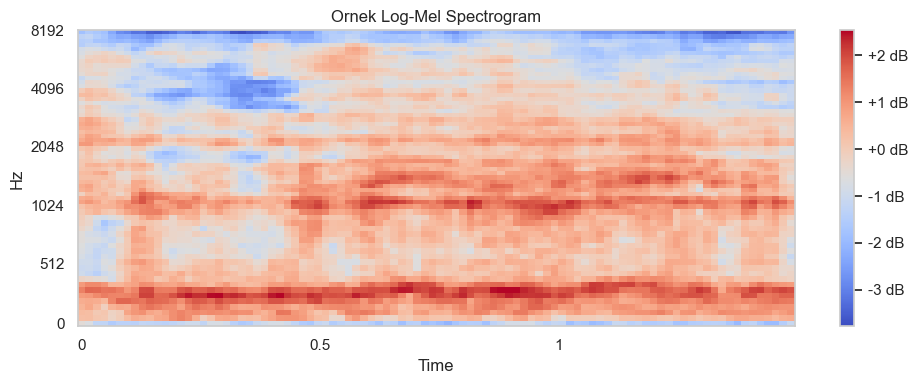

In [8]:
def waveform_to_logmel(
    waveform: np.ndarray,
    sr: int = SAMPLE_RATE,
    n_mels: int = N_MELS,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)
    return log_mel.astype(np.float32)


example_logmel = waveform_to_logmel(sample_wave)
print(f"Log-mel boyutu: {example_logmel.shape}")

plt.figure(figsize=(10, 4))
librosa.display.specshow(example_logmel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
plt.title("Ornek Log-Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()


## 9. PyTorch Dataset Class

In [9]:
class NigensBinaryDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, training: bool = False):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.training = training

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        waveform = load_audio(row["path"])
        waveform = crop_or_pad(waveform, training=self.training)
        if self.training:
            waveform = augment_waveform(waveform)
        logmel = waveform_to_logmel(waveform)
        feature = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row["label_idx"]), dtype=torch.long)
        return feature, label


train_dataset = NigensBinaryDataset(train_df, training=True)
val_dataset = NigensBinaryDataset(val_df, training=False)

sample_feature, sample_label = train_dataset[0]
print(f"Feature tensor shape: {sample_feature.shape}")
print(f"Label: {sample_label.item()} -> {IDX_TO_LABEL[sample_label.item()]}")


Feature tensor shape: torch.Size([1, 64, 94])
Label: 0 -> NON_HUMAN


## 10. DataLoader

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Train batches: 17
Val batches: 5


## 11. Kucuk ve Hafif CNN Model

In [11]:
class SmallAudioCNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.15),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


model = SmallAudioCNN(num_classes=len(LABEL_TO_IDX)).to(DEVICE)
model


SmallAudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=64, out_features=32, bias

## 12. Training Loop

In [12]:
def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for features, labels in dataloader:
        features = features.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            logits = model(features)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(dataloader.dataset)
    epoch_acc = float(np.mean(np.array(all_preds) == np.array(all_labels)))
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


## 13. Class Imbalance Icin Class Weights

In [13]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(LABEL_TO_IDX.values())),
    y=train_df["label_idx"].to_numpy(),
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

class_weight_table = pd.DataFrame(
    {
        "label_idx": sorted(LABEL_TO_IDX.values()),
        "label_name": [IDX_TO_LABEL[idx] for idx in sorted(LABEL_TO_IDX.values())],
        "weight": class_weights,
    }
)
display(class_weight_table)


,label_idx,label_name,weight
0,0,NON_HUMAN,0.656642
1,1,HUMAN,2.096000


## 14. En Iyi Modeli Kaydetme

Epoch 01/20 | train_loss=0.6598 train_acc=0.6107 | val_loss=0.6868 val_acc=0.3130 | val_macro_f1=0.2949 val_human_recall=1.0000
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\nigens_best.pt
Epoch 02/20 | train_loss=0.6015 train_acc=0.6908 | val_loss=0.6107 val_acc=0.5878 | val_macro_f1=0.5807 val_human_recall=0.9677
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\nigens_best.pt
Epoch 03/20 | train_loss=0.5322 train_acc=0.7405 | val_loss=0.4957 val_acc=0.7481 | val_macro_f1=0.7222 val_human_recall=0.9355
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\nigens_best.pt
Epoch 04/20 | train_loss=0.4979 train_acc=0.7443 | val_loss=0.5724 val_acc=0.5649 | val_macro_f1=0.5599 val_human_recall=0.9677
Epoch 05/20 | train_loss=0.3987 train_acc=0.8053 | val_loss=0.3863 val_acc=0.8855 | val_macro_f1=0.8496 val_human_recall=0.8387
  -> Yeni en iyi model kaydedildi: C:\projs\echo_swarm2\models\nigens_best.pt
Epoch 06/20 | train_loss=0.4804 train_acc=0.8015

,epoch,train_loss,train_acc,val_loss,val_acc,val_macro_f1,val_human_recall
0,1,0.659822,0.610687,0.686809,0.312977,0.294856,1.000000
1,2,0.601505,0.690840,0.610727,0.587786,0.580725,0.967742
2,3,0.532193,0.740458,0.495663,0.748092,0.722190,0.935484
3,4,0.497933,0.744275,0.572432,0.564885,0.559859,0.967742
4,5,0.398691,0.805344,0.386348,0.885496,0.849598,0.838710
5,6,0.480360,0.801527,0.379382,0.824427,0.797200,0.967742
6,7,0.364895,0.809160,0.399273,0.740458,0.717958,0.967742
7,8,0.362666,0.816794,0.779804,0.809160,0.606607,0.193548
8,9,0.363009,0.877863,0.369504,0.877863,0.841116,0.838710
9,10,0.322437,0.872137,0.277516,0.916031,0.893739,0.967742


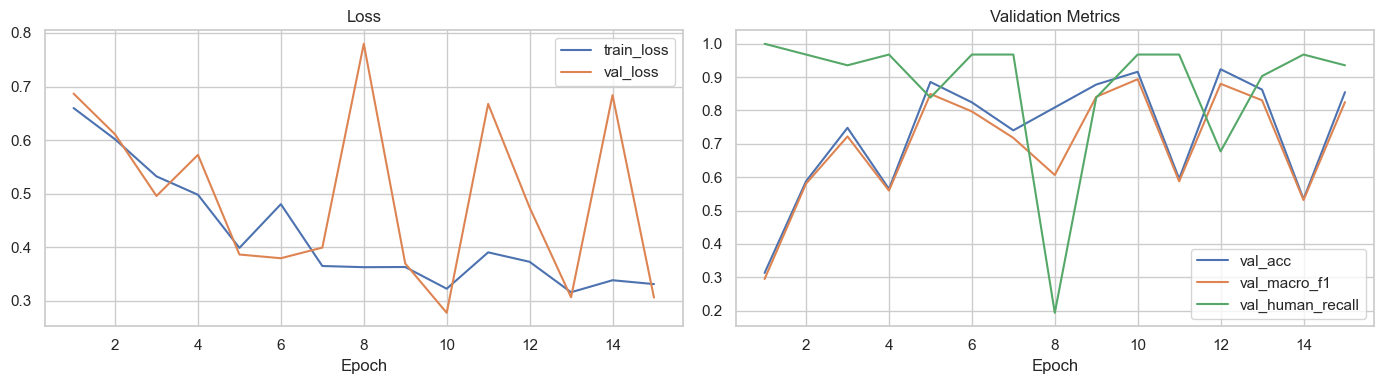

Best val macro F1: 0.8937
Best val HUMAN recall: 0.9677


In [14]:
history = []
best_state_dict = None
best_val_macro_f1 = -1.0
best_val_human_recall = -1.0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc, val_labels, val_preds = run_epoch(model, val_loader, criterion, optimizer=None)

    val_macro_f1 = f1_score(val_labels, val_preds, average="macro")
    val_human_recall = recall_score(val_labels, val_preds, pos_label=LABEL_TO_IDX["HUMAN"])

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
            "val_human_recall": val_human_recall,
        }
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"val_macro_f1={val_macro_f1:.4f} val_human_recall={val_human_recall:.4f}"
    )

    is_better = val_macro_f1 > best_val_macro_f1
    if is_better:
        best_val_macro_f1 = val_macro_f1
        best_val_human_recall = val_human_recall
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        torch.save(
            {
                "model_state_dict": best_state_dict,
                "label_to_idx": LABEL_TO_IDX,
                "config": {
                    "sample_rate": SAMPLE_RATE,
                    "clip_seconds": CLIP_SECONDS,
                    "n_mels": N_MELS,
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                },
            },
            MODEL_PATH,
        )
        patience_counter = 0
        print(f"  -> Yeni en iyi model kaydedildi: {MODEL_PATH}")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping tetiklendi (patience={PATIENCE}).")
        break

if best_state_dict is None:
    raise RuntimeError("Egitim sirasinda en iyi model olusturulamadi.")

model.load_state_dict(best_state_dict)
history_df = pd.DataFrame(history)
display(history_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
axes[1].plot(history_df["epoch"], history_df["val_human_recall"], label="val_human_recall")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best val macro F1: {best_val_macro_f1:.4f}")
print(f"Best val HUMAN recall: {best_val_human_recall:.4f}")


## 15. Evaluation

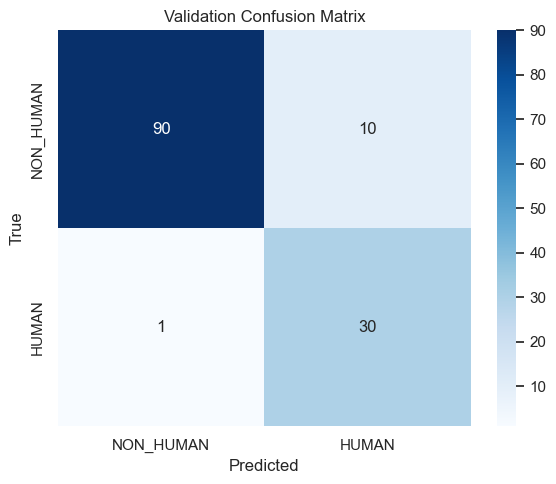

,precision,recall,f1-score,support
NON_HUMAN,0.989011,0.900000,0.942408,100.000000
HUMAN,0.750000,0.967742,0.845070,31.000000
accuracy,0.916031,0.916031,0.916031,0.916031
macro avg,0.869505,0.933871,0.893739,131.000000
weighted avg,0.932451,0.916031,0.919374,131.000000


              precision    recall  f1-score   support

   NON_HUMAN     0.9890    0.9000    0.9424       100
       HUMAN     0.7500    0.9677    0.8451        31

    accuracy                         0.9160       131
   macro avg     0.8695    0.9339    0.8937       131
weighted avg     0.9325    0.9160    0.9194       131

HUMAN recall: 0.9677


In [15]:
def predict_dataframe(model, dataframe: pd.DataFrame):
    dataset = NigensBinaryDataset(dataframe, training=False)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    probs_list = []
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE, non_blocking=True)
            logits = model(features)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            probs_list.extend(probs[:, LABEL_TO_IDX["HUMAN"]].cpu().numpy().tolist())
            preds_list.extend(preds.cpu().numpy().tolist())
            labels_list.extend(labels.numpy().tolist())

    return np.array(labels_list), np.array(preds_list), np.array(probs_list)


val_labels, val_preds, val_human_probs = predict_dataframe(model, val_df)
cm = confusion_matrix(val_labels, val_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
    yticklabels=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

report_dict = classification_report(
    val_labels,
    val_preds,
    labels=[0, 1],
    target_names=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
    digits=4,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

print(
    classification_report(
        val_labels,
        val_preds,
        labels=[0, 1],
        target_names=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
        digits=4,
        zero_division=0,
    )
)

human_recall = report_dict["HUMAN"]["recall"]
print(f"HUMAN recall: {human_recall:.4f}")


## 16. Tek WAV Dosyasi Icin Inference

In [16]:
def load_checkpoint_for_inference(model_path: Path):
    checkpoint = torch.load(model_path, map_location=DEVICE)
    inference_model = SmallAudioCNN(num_classes=len(checkpoint["label_to_idx"])).to(DEVICE)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()
    return inference_model, checkpoint


def predict_single_wav(wav_path: str, model_path: Path = MODEL_PATH):
    inference_model, checkpoint = load_checkpoint_for_inference(model_path)
    waveform = load_audio(wav_path, target_sr=checkpoint["config"]["sample_rate"])
    waveform = crop_or_pad(waveform, target_length=int(checkpoint["config"]["sample_rate"] * checkpoint["config"]["clip_seconds"]), training=False)
    logmel = waveform_to_logmel(
        waveform,
        sr=checkpoint["config"]["sample_rate"],
        n_mels=checkpoint["config"]["n_mels"],
        n_fft=checkpoint["config"]["n_fft"],
        hop_length=checkpoint["config"]["hop_length"],
    )
    feature = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = inference_model(feature)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    predicted_idx = int(np.argmax(probs))
    predicted_label = IDX_TO_LABEL[predicted_idx]
    human_prob = float(probs[LABEL_TO_IDX["HUMAN"]])
    nonhuman_prob = float(probs[LABEL_TO_IDX["NON_HUMAN"]])

    return {
        "wav_path": wav_path,
        "predicted_label": predicted_label,
        "human_probability": human_prob,
        "non_human_probability": nonhuman_prob,
    }


INFER_WAV_PATH = r"C:\projs\echo_swarm2\demo_samples\nigens_quick_test\non_human\nonhuman_01_alarm.wav"



if INFER_WAV_PATH:
    inference_result = predict_single_wav(INFER_WAV_PATH)
    display(pd.DataFrame([inference_result]))
else:
    print("Inference icin INFER_WAV_PATH degiskenine bir .wav dosyasi yolu verin.")


,wav_path,predicted_label,human_probability,non_human_probability
0,C:\projs\echo_swarm2\demo_samples\nigens_quick...,NON_HUMAN,0.186628,0.813372


In [17]:
from pathlib import Path
import pandas as pd

demo_root = Path(r"C:\projs\echo_swarm2\demo_samples\nigens_quick_test")
demo_files = sorted(demo_root.rglob("*.wav"))

results = []
for wav_path in demo_files:
    out = predict_single_wav(str(wav_path))
    results.append(out)

demo_results_df = pd.DataFrame(results)
display(demo_results_df.sort_values("wav_path").reset_index(drop=True))


,wav_path,predicted_label,human_probability,non_human_probability
0,C:\projs\echo_swarm2\demo_samples\nigens_quick...,HUMAN,0.902148,0.097852
1,C:\projs\echo_swarm2\demo_samples\nigens_quick...,HUMAN,0.639066,0.360934
2,C:\projs\echo_swarm2\demo_samples\nigens_quick...,HUMAN,0.828984,0.171015
3,C:\projs\echo_swarm2\demo_samples\nigens_quick...,HUMAN,0.923750,0.076250
4,C:\projs\echo_swarm2\demo_samples\nigens_quick...,NON_HUMAN,0.186628,0.813372
5,C:\projs\echo_swarm2\demo_samples\nigens_quick...,HUMAN,0.571176,0.428824
6,C:\projs\echo_swarm2\demo_samples\nigens_quick...,NON_HUMAN,0.103235,0.896765
7,C:\projs\echo_swarm2\demo_samples\nigens_quick...,NON_HUMAN,0.000595,0.999405


In [18]:
from pathlib import Path
import pandas as pd

rubble_root = Path(r"C:\projs\echo_swarm2\demo_samples\nigens_rubble_test")
manifest = pd.read_csv(r"C:\projs\echo_swarm2\demo_samples\nigens_rubble_test\manifest.csv")

results = []
for wav_path in sorted(rubble_root.rglob("*.wav")):
    out = predict_single_wav(str(wav_path))
    out["variant_name"] = wav_path.name
    results.append(out)

results_df = pd.DataFrame(results)
comparison_df = manifest.merge(results_df, on="variant_name", how="left")

display(
    comparison_df[
        ["variant_name", "target_label", "predicted_label", "human_probability", "non_human_probability"]
    ].sort_values("variant_name").reset_index(drop=True)
)

accuracy = (comparison_df["target_label"] == comparison_df["predicted_label"]).mean()
human_recall = (
    comparison_df.loc[comparison_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean()
)

print(f"Rubble mini-test accuracy: {accuracy:.4f}")
print(f"Rubble HUMAN recall: {human_recall:.4f}")


,variant_name,target_label,predicted_label,human_probability,non_human_probability
0,human_01_femaleSpeech_rubble.wav,HUMAN,NON_HUMAN,0.123756,0.876244
1,human_02_maleSpeech_rubble.wav,HUMAN,NON_HUMAN,0.364814,0.635186
2,human_03_femaleScream_rubble.wav,HUMAN,NON_HUMAN,0.031710,0.968290
3,human_04_maleScream_rubble.wav,HUMAN,HUMAN,0.796527,0.203473
4,nonhuman_01_alarm_rubble.wav,NON_HUMAN,HUMAN,0.585595,0.414405
5,nonhuman_02_dog_rubble.wav,NON_HUMAN,NON_HUMAN,0.246956,0.753044
6,nonhuman_03_engine_rubble.wav,NON_HUMAN,NON_HUMAN,0.137500,0.862500
7,nonhuman_04_fire_rubble.wav,NON_HUMAN,NON_HUMAN,0.020102,0.979898


Rubble mini-test accuracy: 0.5000
Rubble HUMAN recall: 0.2500


## Report Comparison

,experiment_name,project_name,datasets_used,val_accuracy,val_macro_f1,human_recall,quick_test_accuracy,quick_test_human_recall,rubble_test_accuracy,rubble_test_human_recall
0,echo_swarm2_nigens_human_vs_nonhuman,echo_swarm2,NIGENS,0.916031,0.893739,0.967742,0.875,1.0,0.5,0.25
1,echo_swarm_scream_baseline,echo_swarm,human_screaming_detection,0.806400,0.805600,0.894700,NaN,NaN,NaN,NaN


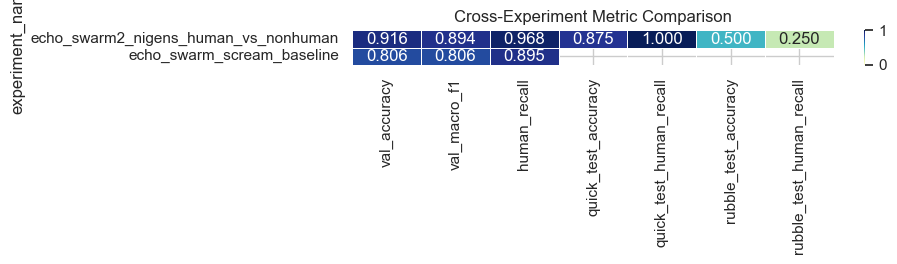

Comparison CSV updated: C:\projs\echo_swarm2\outputs\cross_project_experiment_comparison.csv


In [19]:
# EXPERIMENT_COMPARISON_SECTION
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

COMPARISON_CSV = Path(r"C:\projs\echo_swarm2\outputs\cross_project_experiment_comparison.csv")
COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)
COMPARISON_PNG = COMPARISON_CSV.with_name("cross_project_experiment_comparison_heatmap.png")

def upsert_experiment_row(row: dict, csv_path: Path = COMPARISON_CSV) -> pd.DataFrame:
    new_row = pd.DataFrame([row])
    if csv_path.exists():
        current_df = pd.read_csv(csv_path)
    else:
        current_df = pd.DataFrame(columns=new_row.columns)

    for col in new_row.columns:
        if col not in current_df.columns:
            current_df[col] = pd.NA
    for col in current_df.columns:
        if col not in new_row.columns:
            new_row[col] = pd.NA

    new_row = new_row[current_df.columns]
    current_df = current_df[current_df["experiment_name"] != row["experiment_name"]]
    current_df = pd.concat([current_df, new_row], ignore_index=True)
    current_df.to_csv(csv_path, index=False)
    return current_df

def render_comparison(df: pd.DataFrame) -> None:
    ordered_cols = [
        "experiment_name",
        "project_name",
        "datasets_used",
        "val_accuracy",
        "val_macro_f1",
        "human_recall",
        "quick_test_accuracy",
        "quick_test_human_recall",
        "rubble_test_accuracy",
        "rubble_test_human_recall",
    ]
    show_cols = [col for col in ordered_cols if col in df.columns]
    display(df[show_cols].sort_values("experiment_name").reset_index(drop=True))

    metric_cols = [
        "val_accuracy",
        "val_macro_f1",
        "human_recall",
        "quick_test_accuracy",
        "quick_test_human_recall",
        "rubble_test_accuracy",
        "rubble_test_human_recall",
    ]
    metric_cols = [col for col in metric_cols if col in df.columns and df[col].notna().any()]
    if not metric_cols:
        return

    heatmap_df = df[["experiment_name"] + metric_cols].copy()
    heatmap_df[metric_cols] = heatmap_df[metric_cols].apply(pd.to_numeric, errors="coerce")
    heatmap_df = heatmap_df.set_index("experiment_name").sort_index()

    plt.figure(figsize=(max(8, len(metric_cols) * 1.4), max(2.8, len(heatmap_df) * 0.7)))
    sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", linewidths=0.5)
    plt.title("Cross-Experiment Metric Comparison")
    plt.tight_layout()
    plt.savefig(COMPARISON_PNG, dpi=180, bbox_inches="tight")
    plt.show()

def run_demo_benchmark_for_report(manifest_path: Path, folder_root: Path):
    if not manifest_path.exists():
        return pd.NA, pd.NA
    manifest_df = pd.read_csv(manifest_path)
    rows = []
    for _, row in manifest_df.iterrows():
        if "variant_path" in manifest_df.columns:
            wav_path = row["variant_path"]
        else:
            subfolder = "human" if row["target_label"] == "HUMAN" else "non_human"
            wav_path = str(folder_root / subfolder / row["demo_name"])
        pred = predict_single_wav(wav_path)
        rows.append({"target_label": row["target_label"], "predicted_label": pred["predicted_label"]})
    result_df = pd.DataFrame(rows)
    accuracy = (result_df["target_label"] == result_df["predicted_label"]).mean()
    human_recall_score = result_df.loc[result_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean()
    return float(accuracy), float(human_recall_score)

quick_acc, quick_hrec = run_demo_benchmark_for_report(
    Path(r"C:\projs\echo_swarm2\demo_samples\nigens_quick_test\manifest.csv"),
    Path(r"C:\projs\echo_swarm2\demo_samples\nigens_quick_test"),
)
rubble_acc, rubble_hrec = run_demo_benchmark_for_report(
    Path(r"C:\projs\echo_swarm2\demo_samples\nigens_rubble_test\manifest.csv"),
    Path(r"C:\projs\echo_swarm2\demo_samples\nigens_rubble_test"),
)

summary_row = {
    "experiment_name": "echo_swarm2_nigens_human_vs_nonhuman",
    "project_name": "echo_swarm2",
    "notebook_path": r"C:\projs\echo_swarm2\notebooks\nigens_human_vs_nonhuman.ipynb",
    "datasets_used": "NIGENS",
    "human_definition": "femaleScream,maleScream,femaleSpeech,maleSpeech",
    "nonhuman_definition": "alarm,crash,dog,engine,fire,footsteps,knock,phone,piano,general<=100",
    "val_accuracy": float((val_labels == val_preds).mean()),
    "val_macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "human_recall": float(report_dict["HUMAN"]["recall"]),
    "quick_test_accuracy": quick_acc,
    "quick_test_human_recall": quick_hrec,
    "rubble_test_accuracy": rubble_acc,
    "rubble_test_human_recall": rubble_hrec,
}

comparison_df = upsert_experiment_row(summary_row)
render_comparison(comparison_df)
print(f"Comparison CSV updated: {COMPARISON_CSV}")
